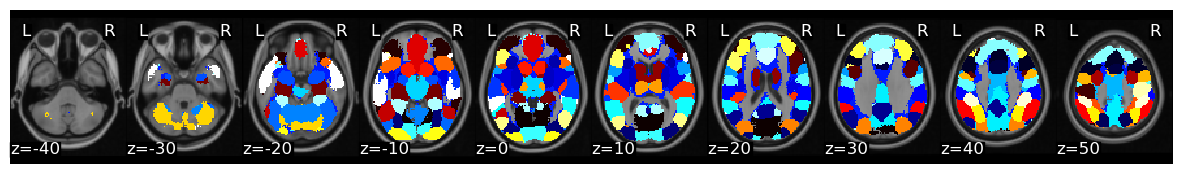

In [9]:
import os
from nltools.mask import expand_mask, roi_to_brain
from nltools.data import Brain_Data, Adjacency

# from fnl_tools.stats import (compute_ISC_all_roi,
#                              create_average_concordance)
from nltools.prefs import MNI_Template
import warnings
warnings.filterwarnings('ignore')

MNI_Template['resolution'] = '2mm' ## mask specify

base_dir = '/Storage/Data/nes/'

mask = Brain_Data(os.path.join(base_dir, 'code_menghan', 'Mask', 'k50_2mm.nii.gz'))
mask.plot()
#expand this mask into 50 separate regions
mask_x = expand_mask(mask) 
mask_x
current_directory = '/Storage/Data/nes_menghan/code_menghan/NeuroExperience/'
svg_file = 'svg_files' ## svg plots

In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

In [3]:
data_dir = '/Storage/Data/nes_menghan/preprocessed/final/'
subj_sids_list = os.listdir(data_dir)
subj_sids_iteration = []
for subj in subj_sids_list:
    subj_path = os.path.join(data_dir, subj)
    subj_path_sess = os.listdir(subj_path)
    if len(subj_path_sess) == 5:
        subj_sids_iteration.append(subj)
    
    
subj_sids_iteration.remove('sub-sid001215') ###the Timepoints of this subject's third session were fewer than others
subj_sids_iteration.remove('sub-sid001473') ### the fifth

subj_sids_iteration.remove('sub-sid000860') 
subj_sids_iteration.remove('sub-sid001201')  ### head coil issue: HEP
print(len(subj_sids_iteration))
subj_sids_iteration

20


['sub-sid001377',
 'sub-sid001277',
 'sub-sid001280',
 'sub-sid001367',
 'sub-sid000846',
 'sub-sid001274',
 'sub-sid001397',
 'sub-sid001358',
 'sub-sid001276',
 'sub-sid000381',
 'sub-sid001286',
 'sub-sid001282',
 'sub-sid000854',
 'sub-sid001555',
 'sub-sid001291',
 'sub-sid000780',
 'sub-sid001302',
 'sub-sid001296',
 'sub-sid001278',
 'sub-sid000861']

In [4]:
import pandas as pd

onset_movie = os.path.join('/Storage/Data/nes_menghan/', 'code_menghan', 'NeuroExperience','onset_movie.txt')

onset_movie = pd.read_csv(onset_movie,sep='\t').set_index('Movie name')
onset_movie

,Scanning run,Starting TR,Ending TR,Trim_Starting TR,Trim_Ending TR,Entire Onset,Entire Ending
Movie name,,,,,,,
Nature,run1,8,52,3,47,3,47
Asian cake,run1,62,185,57,180,57,180
Ribbon climbing,run1,194,335,189,330,189,330
Kiss me,run1,344,485,339,480,339,480
Syrian,run1,495,584,490,579,490,579
Salad,run2,8,138,3,133,591,721
Angelina Hale,run2,147,277,142,272,730,860
Soccer,run2,285,410,280,405,868,993
Dancing lady,run2,419,529,414,524,1002,1112


### Within averaged spatial

In [5]:
def _run_one_region(roi_num):
#     nonlocal data_dir
    
    session_num = 5
    task_num = 5

    subj_spatiotemporal_all = []

    for sub_name in tqdm(subj_sids_iteration):
        data_subj_session = pd.DataFrame([])
        subj_spatiotemporal = []
        isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI_spatial',f"{sub_name}_ses*_task-movie*_Denoised_ROI{roi_num}.csv"))
        isc_data.sort()
        
        isc_data_test = pd.read_csv(isc_data[0])
        subj_data_spatiotemporal = np.empty((2966,isc_data_test.shape[1],5))

        for i in range(session_num):
            isc_data_session = isc_data[i*5:i*5+5]
            data_subj_session = pd.DataFrame([])
            for j in range(task_num):
                isc_data_session_task = pd.read_csv(isc_data_session[j])
                if len(data_subj_session) == 0:
                    data_subj_session = isc_data_session_task
                else:
                    data_subj_session = np.concatenate((data_subj_session,isc_data_session_task),axis = 0)

            subj_data_spatiotemporal[:,:,i] = data_subj_session


        for tp in range(2966):
            session_similarity = pd.DataFrame(subj_data_spatiotemporal[tp,:,:]).corr().to_numpy()
            session_similarity = np.arctanh(session_similarity)
            session_similarity_trail = session_similarity[np.triu_indices(5, 1)]
            subj_spatiotemporal.append(np.mean(session_similarity_trail))

        subj_spatiotemporal_all.append(subj_spatiotemporal)

    ## extract video data    
    subj_spatiotemporal_all_df = pd.DataFrame(subj_spatiotemporal_all)
    subj_spatiotemporal_video = pd.DataFrame([])
    for videonum in range(24):
        video_within = subj_spatiotemporal_all_df.iloc[:,onset_movie['Entire Onset'][videonum]:onset_movie['Entire Ending'][videonum]+1]
        subj_spatiotemporal_video = pd.concat([subj_spatiotemporal_video,video_within], axis = 1)

    spatiotemporal_corr = subj_spatiotemporal_video.mean(axis = 0)
    spatiotemporal_corr_mean = spatiotemporal_corr.mean()
    
    

    return spatiotemporal_corr_mean


In [6]:
from joblib import Parallel, delayed
result = Parallel(n_jobs=10)(delayed(_run_one_region)(roi_num=filep) for filep in tqdm(range(50)))


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWa

  0%|          | 0/20 [00:00<?, ?it/s]


/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh


  0%|          | 0/20 [00:00<?, ?it/s]


/tmp/ipykernel_1545316/4294153085.py:33: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/4294153085.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


  0%|          | 0/20 [00:00<?, ?it/s]


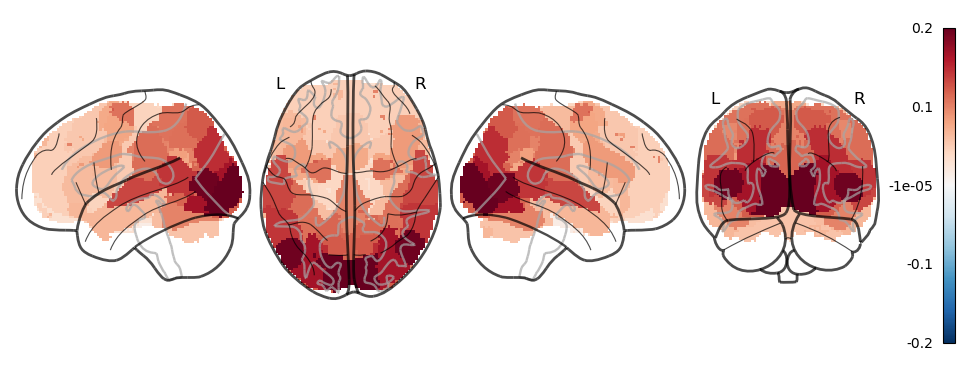

In [10]:

from nilearn.plotting import plot_glass_brain

# sns.set(font_scale=0.8)

spatiotemporal_brain = roi_to_brain(result, mask_x)
plot_glass_brain(spatiotemporal_brain.to_nifti(), display_mode='lzry',colorbar=True,cmap='RdBu_r',plot_abs=False, symmetric_cbar=True)
plt.savefig(os.path.join(current_directory,svg_file,"averaged_spatial_within_similarity.svg"), format="svg")

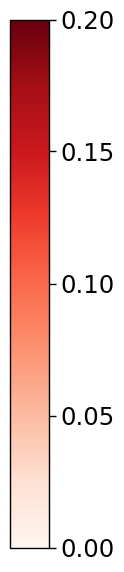

In [15]:

import matplotlib as mpl
with sns.plotting_context(context='paper', font_scale=2):
    fig, ax = plt.subplots(figsize=(0.5, 6))
    fig.subplots_adjust(bottom=0)

    cmap = mpl.cm.Reds
    norm = mpl.colors.Normalize(vmin=0, vmax=0.2)
    cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', ticks=np.linspace(0, 0.2, 5))
    plt.tight_layout()
    plt.savefig(os.path.join(current_directory,svg_file,"averaged_spatial_within_similarity_cmap.svg"), format="svg")

### Between averaged spatial

In [16]:



task_num = 5

def spatiotemporal_between_subjects(roi_num,session_num):

    subj_spatiotemporal_all = []

    isc_data_test = pd.read_csv(glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI_spatial',f"{subj_sids_iteration[0]}_ses-1_task-movie1_Denoised_ROI{roi_num}.csv"))[0])
    subj_data_spatiotemporal = np.empty((2966,isc_data_test.shape[1],20))


    for subj_num,sub_name in tqdm(enumerate(subj_sids_iteration)):
        data_subj_session = pd.DataFrame([])
        subj_spatiotemporal = []
        isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI_spatial',f"{sub_name}_ses-{session_num}_task-movie*_Denoised_ROI{roi_num}.csv"))
        isc_data.sort()

        data_subj_session = pd.DataFrame([])
        for j in range(task_num):
            isc_data_session_task = pd.read_csv(isc_data[j])
            if len(data_subj_session) == 0:
                data_subj_session = isc_data_session_task
            else:
                data_subj_session = np.concatenate((data_subj_session,isc_data_session_task),axis = 0)

        ## data_subj_session.shape = (2966-TP, voxel number)
        subj_data_spatiotemporal[:,:,subj_num] = data_subj_session


    for tp in tqdm(range(2966)):
        session_similarity = pd.DataFrame(subj_data_spatiotemporal[tp,:,:]).corr().to_numpy()
        session_similarity = np.arctanh(session_similarity)
        session_similarity_trail = session_similarity[np.triu_indices(20, 1)]

        subj_spatiotemporal_all.append(np.mean(session_similarity_trail))

    
    return subj_spatiotemporal_all
    

In [17]:
from joblib import Parallel, delayed
result_between1 = Parallel(n_jobs=10)(delayed(spatiotemporal_between_subjects)(roi_num=filep, session_num=1) for filep in tqdm(range(50)))
spatiotemporal_between_subject_video = np.array(result_between1)
spatiotemporal_between_subject_video.shape

  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divi

(50, 2966)

0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/29

In [18]:
roi_spatiotemporal = []
for i in range(50):
    roi_between_subject_video = pd.DataFrame([])
    for videonum in range(24):
        video_within = spatiotemporal_between_subject_video[i,onset_movie['Entire Onset'][videonum]:onset_movie['Entire Ending'][videonum]+1]
        roi_between_subject_video = pd.concat([roi_between_subject_video,pd.DataFrame(video_within)], axis = 0)
    roi_spatiotemporal.append(roi_between_subject_video.mean().iloc[0])


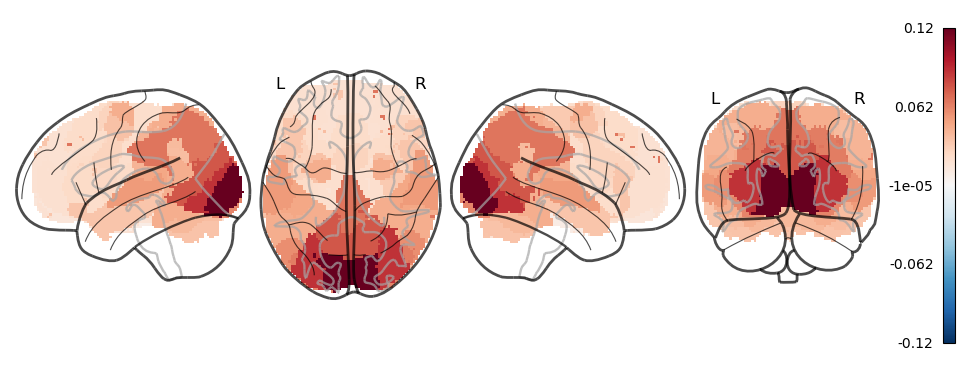

In [20]:
import warnings
warnings.filterwarnings('ignore')
from nilearn.plotting import plot_glass_brain

# sns.set(font_scale=0.8)

roi_spatiotemporal_brain = roi_to_brain(roi_spatiotemporal, mask_x)
plot_glass_brain(roi_spatiotemporal_brain.to_nifti(), display_mode='lzry',colorbar=True,cmap='RdBu_r',plot_abs=False, symmetric_cbar=True)
plt.savefig(os.path.join(current_directory,svg_file,"averaged_spatial_between1_similarity.svg"), format="svg")

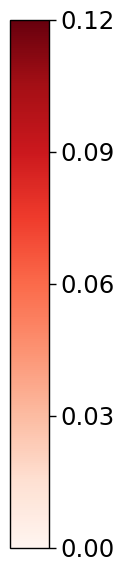

In [21]:
with sns.plotting_context(context='paper', font_scale=2):
    fig, ax = plt.subplots(figsize=(0.5, 6))
    fig.subplots_adjust(bottom=0)

    cmap = mpl.cm.Reds
    norm = mpl.colors.Normalize(vmin=0, vmax=0.12)
    cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', ticks=np.linspace(0, 0.12, 5))
    plt.tight_layout()
    plt.savefig(os.path.join(current_directory,svg_file,"averaged_spatial_between1_similarity_cmap.svg"), format="svg")

### last session between ISC

In [22]:
result = Parallel(n_jobs=10)(delayed(spatiotemporal_between_subjects)(roi_num=filep, session_num=5) for filep in tqdm(range(50)))
spatiotemporal_between_subject_video_five = np.array(result)

roi_spatiotemporal_five = []
for i in range(50):
    roi_between_subject_video_five = pd.DataFrame([])
    for videonum in range(24):
        video_within = spatiotemporal_between_subject_video_five[i,onset_movie['Entire Onset'][videonum]:onset_movie['Entire Ending'][videonum]+1]
        roi_between_subject_video_five = pd.concat([roi_between_subject_video_five,pd.DataFrame(video_within)], axis = 0)
    roi_spatiotemporal_five.append(roi_between_subject_video_five.mean().iloc[0])



  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divide by zero encountered in arctanh
/tmp/ipykernel_1545316/979743321.py:31: RuntimeWarning: divi

0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/2966 [00:00<?, ?it/s]
0it [00:00, ?it/s]
  0%|          | 0/29

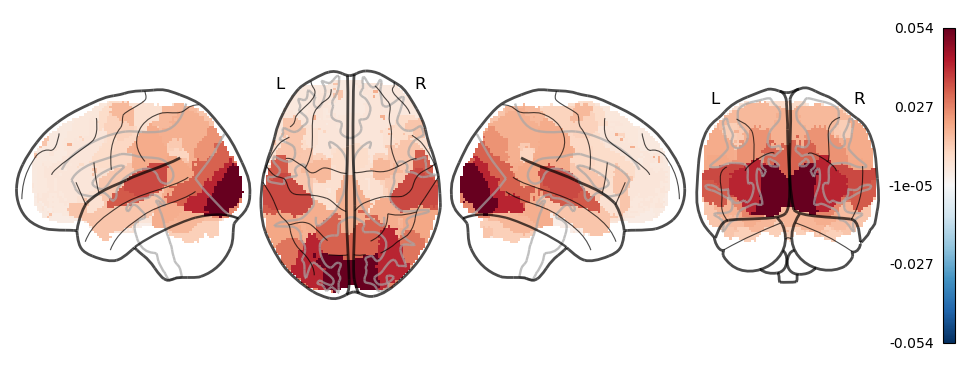

In [25]:
roi_spatiotemporal_five_brain = roi_to_brain(roi_spatiotemporal_five, mask_x)
plot_glass_brain(roi_spatiotemporal_five_brain.to_nifti(), display_mode='lzry',colorbar=True,cmap='RdBu_r',plot_abs=False, symmetric_cbar=True)
plt.savefig(os.path.join(current_directory,svg_file,"averaged_spatial_between5_similarity.svg"), format="svg")


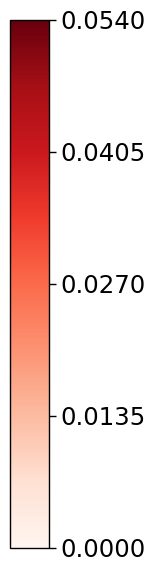

In [26]:
with sns.plotting_context(context='paper', font_scale=2):
    fig, ax = plt.subplots(figsize=(0.5, 6))
    fig.subplots_adjust(bottom=0)

    cmap = mpl.cm.Reds
    norm = mpl.colors.Normalize(vmin=0, vmax=0.054)
    cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', ticks=np.linspace(0, 0.054, 5))
    plt.tight_layout()
    plt.savefig(os.path.join(current_directory,svg_file,"averaged_spatial_between5_similarity_cmap.svg"), format="svg")

## between-subject similarities drop across sessions

In [27]:
sess_all = [1,2,3,4,5]

roi_spatiotemporal_V1 = []
roi_between_subject_video = pd.DataFrame([])

for sess_num in sess_all:
    
    spatiotemporal_between_subject_video_V1 = np.array(spatiotemporal_between_subjects(4,sess_num))
    
    video_between_pd = pd.DataFrame([])
    for videonum in range(24):
        spatiotemporal_between_subject_video_V1.shape
        video_between = spatiotemporal_between_subject_video_V1[onset_movie['Entire Onset'][videonum]:onset_movie['Entire Ending'][videonum]+1]
        video_between_pd = pd.DataFrame(video_between,columns=['between subject similarity'])
        video_between_pd['session time'] = sess_num
        roi_between_subject_video = pd.concat([roi_between_subject_video,video_between_pd], axis = 0)
   
    



0it [00:00, ?it/s]

  0%|          | 0/2966 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/2966 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/2966 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/2966 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/2966 [00:00<?, ?it/s]

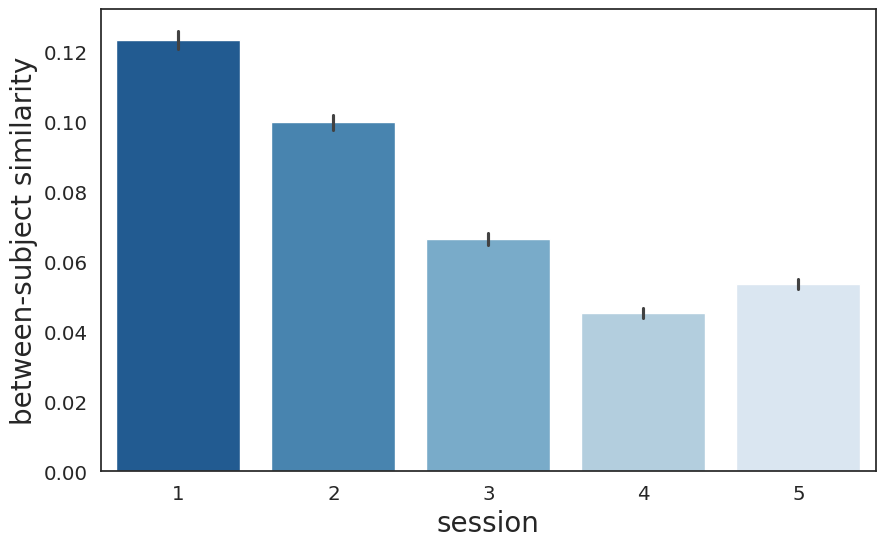

In [28]:
import seaborn as sns
roi_between_subject_video = roi_between_subject_video.rename(columns={'between subject similarity': 'between-subject similarity'})

sns.set(font_scale=1.3)
sns.set_style('white')
plt.figure(figsize=(10,6))
sns.barplot(data =roi_between_subject_video, x = 'session time', y = 'between-subject similarity',palette = "Blues_r")
plt.xlabel('session',fontsize=20);
plt.ylabel('between-subject similarity',fontsize=20);

plt.savefig(os.path.join(current_directory,svg_file,"V1_session_between_averaged_spatial.svg"), format="svg")

In [29]:
sess_all = [1,2,3,4,5]

roi_spatiotemporal_vmPFC = []
roi_between_subject_video_vmPFC = pd.DataFrame([])

for sess_num in sess_all:
    
    spatiotemporal_between_subject_video_vmPFC = np.array(spatiotemporal_between_subjects(32,sess_num))
    
    video_between_pd = pd.DataFrame([])
    for videonum in range(24):

        video_between = spatiotemporal_between_subject_video_vmPFC[onset_movie['Entire Onset'][videonum]:onset_movie['Entire Ending'][videonum]+1]
        video_between_pd = pd.DataFrame(video_between,columns=['between-subject similarity'])
        video_between_pd['session time'] = sess_num
        roi_between_subject_video_vmPFC = pd.concat([roi_between_subject_video_vmPFC,video_between_pd], axis = 0)
   
    



0it [00:00, ?it/s]

  0%|          | 0/2966 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/2966 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/2966 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/2966 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/2966 [00:00<?, ?it/s]

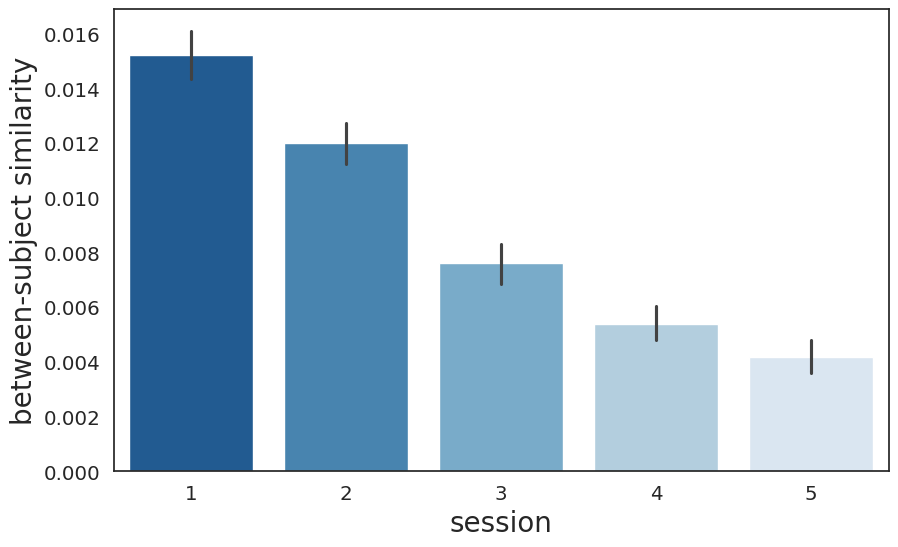

In [30]:
sns.set(font_scale=1.3)
sns.set_style('white')
plt.figure(figsize=(10,6))
sns.barplot(data =roi_between_subject_video_vmPFC, x = 'session time', y = 'between-subject similarity',palette = "Blues_r")
plt.xlabel('session',fontsize=20);
plt.ylabel('between-subject similarity',fontsize=20);

plt.savefig(os.path.join(current_directory,svg_file,"vmPFC_session_between_averaged_spatial.svg"), format="svg")